In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
DATA_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC")

METADATA_PATH = DATA_DIR / "metadata.csv"
IMAGE_DIR = DATA_DIR / "images"

OUTPUT_SPLIT_DIR = Path("/content/drive/MyDrive/bachelor-thesis-data/splits")
OUTPUT_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

Number of rows, columns: 11720, 18
Number of unique images: 11720
Number of unique lesions: 8838
Number of diagnoses classes: 7

                              count  percentage
diagnosis                                      
Nevus                          7737       67.05
Pigmented benign keratosis     1338       11.59
Melanoma, NOS                  1305       11.31
Basal cell carcinoma            622        5.39
Squamous cell carcinoma, NOS    229        1.98
Dermatofibroma                  160        1.39
Solar or actinic keratosis      149        1.29


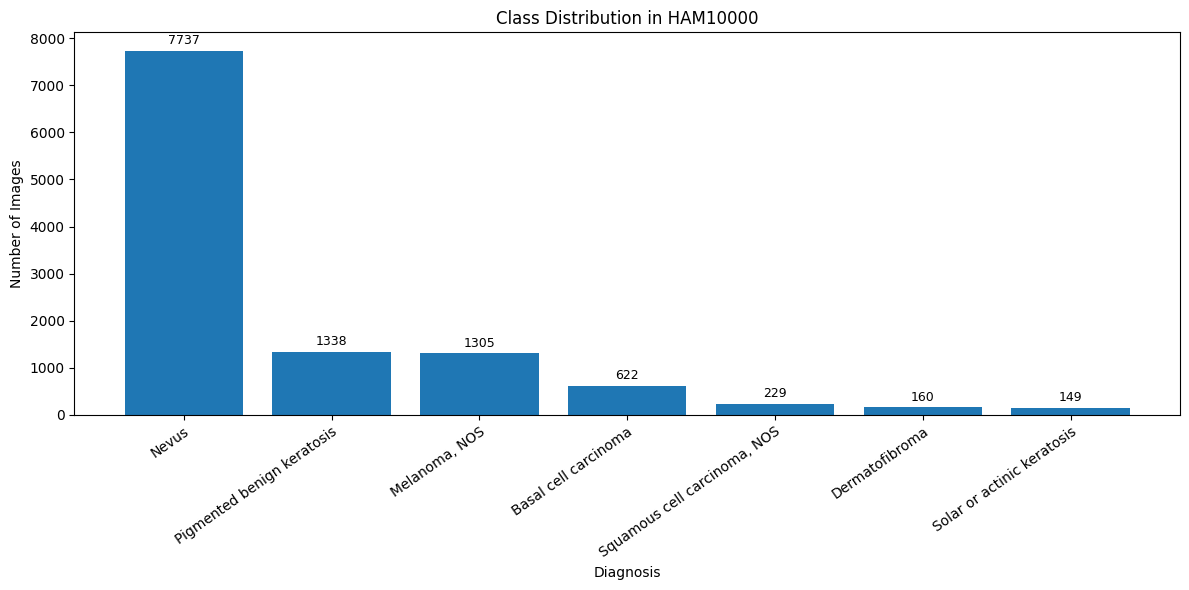

In [4]:
df = pd.read_csv(METADATA_PATH)

print(f"Number of rows, columns: {df.shape[0]}, {df.shape[1]}")
print(f"Number of unique images: {df["isic_id"].nunique()}")
print(f"Number of unique lesions: {df["lesion_id"].nunique()}")
print(f"Number of diagnoses classes: {df["diagnosis_3"].nunique()}\n")

counts = df["diagnosis_3"].value_counts()
percentages = df["diagnosis_3"].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({ 
    "count": counts,
    "percentage": percentages.round(2)
})
class_distribution.index.name = "diagnosis"

print(class_distribution)

labels = class_distribution.index.tolist()
values = class_distribution["count"].values

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(range(len(labels)), values)

ax.set_title("Class Distribution in HAM10000")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of Images")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    rotation=35,
    ha="right",
    rotation_mode="anchor"
)

# Optional: add count labels above bars
for i, value in enumerate(values):
    ax.text(
        i,
        value + max(values) * 0.01,
        str(value),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

# Optional: save figure for thesis
FIGURE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURE_DIR / "ham10000_original_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

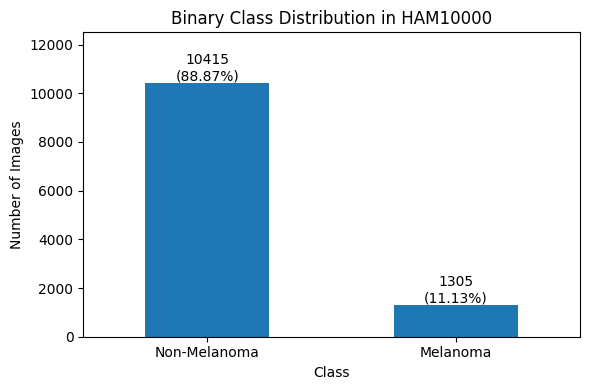

In [4]:
df["binary_label"] = df["diagnosis_3"].apply(
    lambda x: "Melanoma" if x == "Melanoma, NOS" else "Non-Melanoma"
)

binary_counts = df["binary_label"].value_counts()
binary_percentages = df["binary_label"].value_counts(normalize=True) * 100

binary_distribution = pd.DataFrame({
    "count": binary_counts,
    "percentage": binary_percentages.round(2)
})

binary_distribution.index.name = "class"

ax = binary_distribution["count"].plot(kind="bar", figsize=(6, 4))

plt.title("Binary Class Distribution in HAM10000")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

for i, value in enumerate(binary_distribution["count"]):
    percentage = binary_distribution["percentage"].iloc[i]
    ax.text(i, value + 100, f"{value}\n({percentage}%)", ha="center")

plt.tight_layout()
plt.ylim(0, 12500)
plt.show()

In [5]:
missing = df.isnull().sum()
print(f"{missing}\n")

missing_diagnosis = df[df["diagnosis_3"].isnull()]

missing_diagnosis[
    ["isic_id", "lesion_id", "diagnosis_1", "diagnosis_2", "diagnosis_3"]
].head(20)

print(missing_diagnosis["diagnosis_1"].value_counts(dropna=False))
print(missing_diagnosis["diagnosis_2"].value_counts(dropna=False))

#Although 180 rows had missing values in `diagnosis_3`, they were retained because `diagnosis_1` identified them as benign 
#and `diagnosis_2` classified them as benign vascular soft tissue proliferations. 
#Since the classification task is binary melanoma vs non-melanoma, these cases were assigned to the non-melanoma class.

isic_id                       0
attribution                   0
copyright_license             0
age_approx                  383
anatom_site_1               581
anatom_site_2              5804
anatom_site_3              9038
anatom_site_special       11183
concomitant_biopsy            0
diagnosis_1                   0
diagnosis_2                   0
diagnosis_3                 180
diagnosis_confirm_type        0
image_manipulation        11719
image_type                    1
lesion_id                     0
melanocytic                   0
sex                         343
binary_label                  0
dtype: int64

diagnosis_1
Benign    180
Name: count, dtype: int64
diagnosis_2
Benign soft tissue proliferations - Vascular    180
Name: count, dtype: int64


In [6]:
lesion_counts = df["lesion_id"].value_counts()

num_images = len(df)
num_unique_lesions = df["lesion_id"].nunique()
lesions_with_multiple_images = lesion_counts[lesion_counts > 1]

print(f"Number of images: {num_images}")
print(f"Number of unique lesions: {num_unique_lesions}\n")
print(f"Lesions with more than one image: {len(lesions_with_multiple_images)}")
print(f"Maximum number of images for one lesion: {lesion_counts.max()}\n")
print(f"Percentage of lesions with multiple images: {(len(lesions_with_multiple_images) / num_unique_lesions) * 100:.2f}%")

lesion_counts.head(10)


Number of images: 11720
Number of unique lesions: 8838

Lesions with more than one image: 2221
Maximum number of images for one lesion: 6

Percentage of lesions with multiple images: 25.13%


,count
lesion_id,
IL_1017066,6
IL_1795129,6
IL_2755785,6
IL_2334846,6
IL_4551923,5
IL_3857855,5
IL_4222523,5
IL_1446570,5
IL_8711548,5


In [11]:
print(IMAGE_DIR.exists)

image_files = (
    list(IMAGE_DIR.rglob("*.jpg")) +
    list(IMAGE_DIR.rglob("*.jpeg")) +
    list(IMAGE_DIR.rglob("*.png"))
)

image_ids_from_files = set([file.stem for file in image_files])
image_ids_from_metadata = set(df["isic_id"].astype(str))

metadata_without_image = image_ids_from_metadata - image_ids_from_files
images_without_metadata = image_ids_from_files - image_ids_from_metadata

print(f"Images listed in metadata: {len(image_ids_from_metadata)}")
print(f"Image files found: {len(image_ids_from_files)}")
print(f"Metadata rows without matching image file: {len(metadata_without_image)}")
print(f"Image files without metadata row: {len(images_without_metadata)}")

if len(metadata_without_image) > 0:
    print("Example metadata IDs without image file:")
    print(list(metadata_without_image)[:10])

if len(images_without_metadata) > 0:
    print("Example image files without metadata row:")
    print(list(images_without_metadata)[:10])

image_path_map = {file.stem: str(file) for file in image_files}
df["image_path"] = df["isic_id"].map(image_path_map)

print(f"Missing image paths in dataframe: {df['image_path'].isnull().sum()}")

<bound method Path.exists of PosixPath('/content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images')>
Images listed in metadata: 11720
Image files found: 11720
Metadata rows without matching image file: 0
Image files without metadata row: 0
Missing image paths in dataframe: 0


In [18]:
from sklearn.model_selection import GroupShuffleSplit

df["label"] = df["binary_label"].map({
    "Non-Melanoma": 0,
    "Melanoma": 1
})

df[["diagnosis_3", "binary_label", "label"]].head()

required_columns = ["isic_id", "lesion_id", "diagnosis_3", "binary_label", "label", "image_path"]

df_split = df[required_columns].copy()

df_split["diagnosis_3"] = df_split["diagnosis_3"].fillna("Benign vascular lesion")

print(df_split["binary_label"].value_counts())
print(df_split["label"].value_counts())
print("Missing labels:", df_split["label"].isnull().sum())

df_split["label"] = df_split["label"].astype(int)

print(df_split.head())
print(df_split.isnull().sum())

RANDOM_STATE = 42

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
)

train_val_idx, test_idx = next(
    gss_test.split(
        df_split,
        y=df_split["label"],
        groups=df_split["lesion_id"]
    )
)

train_val_df = df_split.iloc[train_val_idx].reset_index(drop=True)
test_df = df_split.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1765,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    gss_val.split(
        train_val_df,
        y=train_val_df["label"],
        groups=train_val_df["lesion_id"]
    )
)

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

print("Train/Val overlap:", len(train_lesions & val_lesions))
print("Train/Test overlap:", len(train_lesions & test_lesions))
print("Val/Test overlap:", len(val_lesions & test_lesions))

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

def check_split_distribution(name, split_df):
    total = len(split_df)
    melanoma = (split_df["label"] == 1).sum()
    non_melanoma = (split_df["label"] == 0).sum()
    melanoma_percentage = melanoma / total * 100

    return {
        "split": name,
        "total": total,
        "melanoma": melanoma,
        "non_melanoma": non_melanoma,
        "melanoma_percentage": round(melanoma_percentage, 2)
    }

split_distribution = pd.DataFrame([
    check_split_distribution("train", train_df),
    check_split_distribution("validation", val_df),
    check_split_distribution("test", test_df)
])

split_distribution

binary_label
Non-Melanoma    10415
Melanoma         1305
Name: count, dtype: int64
label
0    10415
1     1305
Name: count, dtype: int64
Missing labels: 0
        isic_id   lesion_id    diagnosis_3  binary_label  label  \
0  ISIC_0024306  IL_7252831          Nevus  Non-Melanoma      0   
1  ISIC_0024307  IL_6125741          Nevus  Non-Melanoma      0   
2  ISIC_0024308  IL_3692653          Nevus  Non-Melanoma      0   
3  ISIC_0024309  IL_0959663          Nevus  Non-Melanoma      0   
4  ISIC_0024310  IL_8194852  Melanoma, NOS      Melanoma      1   

                                          image_path  
0  /content/drive/MyDrive/bachelor_thesis_data/HA...  
1  /content/drive/MyDrive/bachelor_thesis_data/HA...  
2  /content/drive/MyDrive/bachelor_thesis_data/HA...  
3  /content/drive/MyDrive/bachelor_thesis_data/HA...  
4  /content/drive/MyDrive/bachelor_thesis_data/HA...  
isic_id         0
lesion_id       0
diagnosis_3     0
binary_label    0
label           0
image_path      0
dtyp

,split,total,melanoma,non_melanoma,melanoma_percentage
0,train,8204,943,7261,11.49
1,validation,1742,193,1549,11.08
2,test,1774,169,1605,9.53


In [20]:
SPLIT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

split_distribution.to_csv(SPLIT_DIR / "split_distribution.csv", index=False)

print("Split distribution saved to:")
print(SPLIT_DIR / "split_distribution.csv")

train_df.to_csv(SPLIT_DIR / "train_split.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val_split.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test_split.csv", index=False)

print("All split files saved successfully.")

list(SPLIT_DIR.iterdir())

print(split_distribution.to_string(index=False))

Split distribution saved to:
/content/drive/MyDrive/bachelor_thesis_data/splits/split_distribution.csv
All split files saved successfully.
     split  total  melanoma  non_melanoma  melanoma_percentage
     train   8204       943          7261                11.49
validation   1742       193          1549                11.08
      test   1774       169          1605                 9.53
